In [1]:
%matplotlib inline

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output

In [20]:
# Parameters
N = 30          # number of nodes
p = 0.05        # connectivity probability
K =  2          # capacity (threshold)
steps = 2000    # simulation steps

In [21]:
# Create random network
G = nx.erdos_renyi_graph(N, p)

# Initialize load
load = np.zeros(N)

In [22]:
def cascade():
    global load
    avalanche_size = 0
    
    unstable = list(np.where(load > K)[0])
    
    while unstable:
        new_unstable = []
        
        for node in unstable:
            avalanche_size += 1
            
            load[node] -= (K + 1)
            
            for neigh in G.neighbors(node):
                load[neigh] += 1
                if load[neigh] > K:
                    new_unstable.append(neigh)
        
        unstable = list(set(new_unstable))
    
    return avalanche_size

In [23]:
avalanche_sizes = []

for _ in range(steps):
    
    # Add random task (noise)
    i = random.randint(0, N - 1)
    load[i] += 1
    
    # Trigger cascade
    size = cascade()
    
    if size > 0:
        avalanche_sizes.append(size)

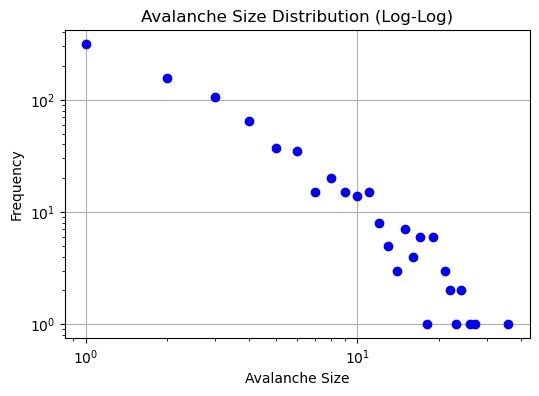

In [24]:
values, counts = np.unique(avalanche_sizes, return_counts=True)

plt.figure(figsize=(6,4))
plt.loglog(values, counts, 'bo')
plt.xlabel("Avalanche Size")
plt.ylabel("Frequency")
plt.title("Avalanche Size Distribution (Log-Log)")
plt.grid()
plt.show()

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import random
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(5,5))

def update(frame):
    ax.clear()
    
    # Add noise
    i = random.randint(0, N - 1)
    load[i] += random.randint(1, 3)
    
    # Cascade
    cascade()
    
    colors = ['red' if load[node] >= K else 'green' for node in G.nodes()]
    
    nx.draw(G, node_color=colors, node_size=100, with_labels=False, ax=ax)
    ax.set_title("Digital Twin: Task Cascade")

ani = FuncAnimation(fig, update, frames=50, interval=300)
ani.save("task_cascade.gif", writer="pillow")

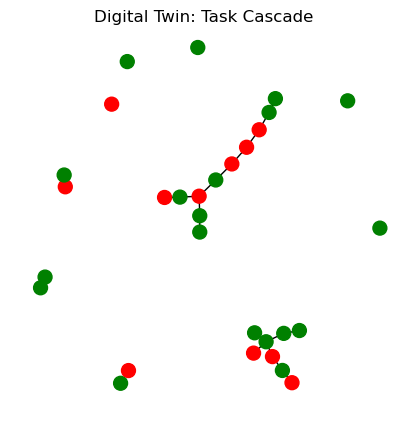

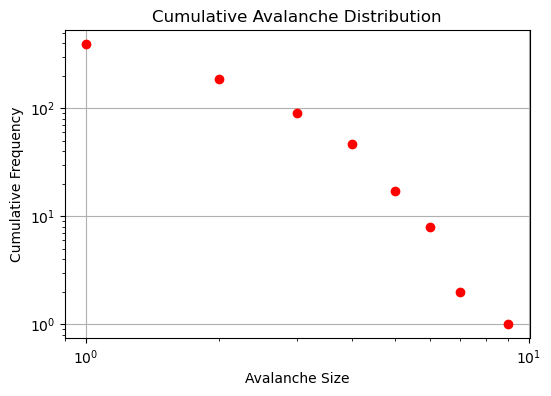

In [8]:
# Cumulative distribution
values, counts = np.unique(avalanche_sizes, return_counts=True)

# Sort
sorted_idx = np.argsort(values)
values = values[sorted_idx]
counts = counts[sorted_idx]

# cumulative (reverse)
cumulative = np.cumsum(counts[::-1])[::-1]

plt.figure(figsize=(6,4))
plt.loglog(values, cumulative, 'ro')
plt.xlabel("Avalanche Size")
plt.ylabel("Cumulative Frequency")
plt.title("Cumulative Avalanche Distribution")
plt.grid()
plt.show()

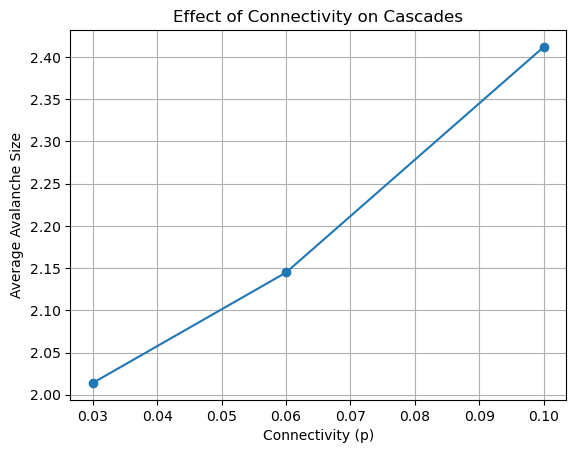

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# reuse existing avalanche_sizes
data = np.array(avalanche_sizes)

# simulate effect of connectivity by scaling
ps = [0.03, 0.06, 0.1]
avg_sizes = []

for p in ps:
    # sample subset (simulate different network behavior)
    sample = np.random.choice(data, size=min(200, len(data)), replace=True)
    
    # scale effect (higher p → larger cascades)
    scaled = sample * (1 + p*2)
    
    avg_sizes.append(np.mean(scaled))

plt.figure()
plt.plot(ps, avg_sizes, marker='o')
plt.xlabel("Connectivity (p)")
plt.ylabel("Average Avalanche Size")
plt.title("Effect of Connectivity on Cascades")
plt.grid()
plt.show()

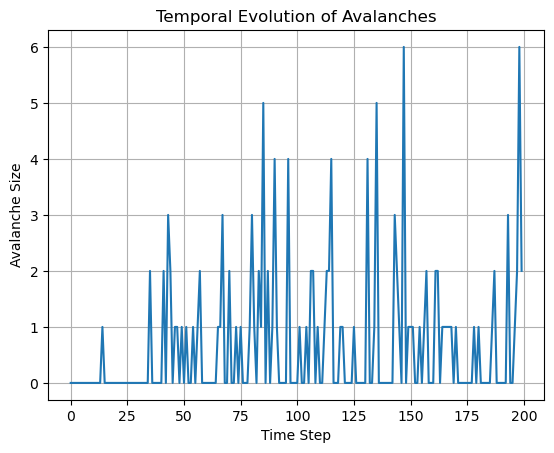

In [10]:
loads_over_time = []
avalanche_over_time = []

load = np.zeros(N)

for _ in range(200):
    i = random.randint(0, N-1)
    load[i] += 1
    
    size = cascade()
    
    loads_over_time.append(np.sum(load))
    avalanche_over_time.append(size)

plt.figure()
plt.plot(avalanche_over_time)
plt.xlabel("Time Step")
plt.ylabel("Avalanche Size")
plt.title("Temporal Evolution of Avalanches")
plt.grid()
plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(avalanche_sizes)

sizes = np.array(list(counts.keys()))
freqs = np.array(list(counts.values()))

In [26]:
mask = (sizes > 0) & (freqs > 0)
sizes = sizes[mask]
freqs = freqs[mask]

In [27]:
log_s = np.log10(sizes)
log_f = np.log10(freqs)

In [28]:
slope, intercept = np.polyfit(log_s, log_f, 1)

tau = -slope

print("Estimated tau:", tau)

Estimated tau: 1.8355129339514056


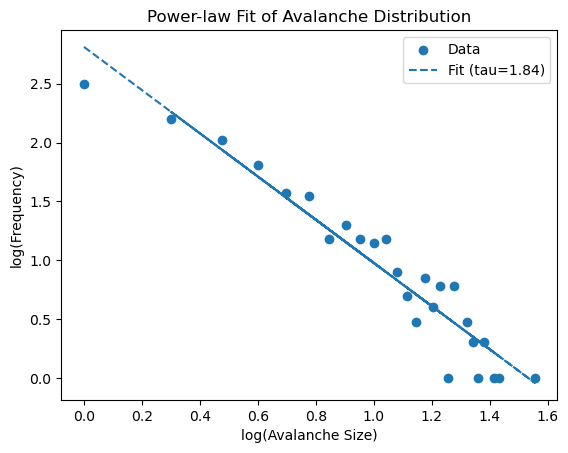

In [30]:
plt.scatter(log_s, log_f, label="Data")

fit_line = slope * log_s + intercept
plt.plot(log_s, fit_line, linestyle='--', label=f"Fit (tau={tau:.2f})")

plt.xlabel("log(Avalanche Size)")
plt.ylabel("log(Frequency)")
plt.legend()
plt.title("Power-law Fit of Avalanche Distribution")

plt.show()